In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

import jax.numpy as jnp
import sax

import tidy3d as td
from tidy3d import web

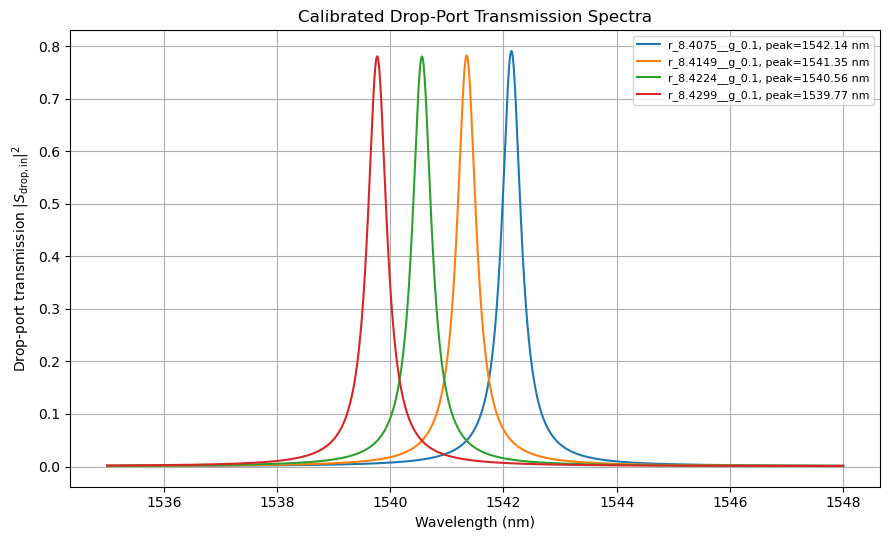

In [35]:
CH44 = 1.54214
CH45 = 1.54135
CH46 = 1.54056
CH47 = 1.53977
def make_phase_clean_coupler_sdict(t_raw, kappa_raw, coupling_sign=+1):
    """
    Passive coupler using raw magnitudes but not raw Tidy3D phases.

    This avoids importing arbitrary monitor/source phase into the closed ring.

    No power normalization is applied.
    """

    t_mag = jnp.abs(jnp.asarray(t_raw))
    k_mag = jnp.abs(jnp.asarray(kappa_raw))

    t = t_mag
    kappa = coupling_sign * 1j * k_mag

    z = jnp.zeros_like(t)

    sdict = {
        # Reflections set to zero
        ("o1", "o1"): z,
        ("o2", "o2"): z,
        ("o3", "o3"): z,
        ("o4", "o4"): z,

        # Same-side direct coupling set to zero
        ("o2", "o1"): z,
        ("o1", "o2"): z,
        ("o4", "o3"): z,
        ("o3", "o4"): z,

        # Forward paths
        ("o4", "o1"): t,
        ("o3", "o1"): kappa,

        ("o3", "o2"): t,
        ("o4", "o2"): kappa,

        # Reverse paths by reciprocity
        ("o1", "o4"): t,
        ("o1", "o3"): kappa,

        ("o2", "o3"): t,
        ("o2", "o4"): kappa,
    }

    return sdict


def make_phase_clean_coupler_model(t_raw, kappa_raw, coupling_sign=+1):
    def coupler(wl=1.55):
        return make_phase_clean_coupler_sdict(
            t_raw=t_raw,
            kappa_raw=kappa_raw,
            coupling_sign=coupling_sign,
        )

    return coupler


def make_calibrated_ring_arc_model(lambda0_um, m=85, half=True, alpha_power_per_um=0.0, radius_um=None):
    """
    Ring propagation section with phase calibrated so that lambda0_um is resonant.

    For a full round trip:
        phi(lambda0) = 2 pi m

    For a half ring:
        phi_half(lambda0) = pi m

    This avoids accidental resonance shifts from arbitrary S-matrix phase.
    """

    phase_factor = np.pi * m if half else 2 * np.pi * m

    if radius_um is not None:
        length_um = np.pi * radius_um if half else 2 * np.pi * radius_um
    else:
        length_um = 1.0

    def arc(wl=1.55):
        wl = jnp.asarray(wl)

        # Constant-neff calibrated phase.
        # At wl = lambda0_um, phase = pi*m for half ring.
        phi = phase_factor * (lambda0_um / wl)

        amp_loss = jnp.exp(-alpha_power_per_um * length_um / 2)

        a = amp_loss * jnp.exp(-1j * phi)

        return {
            ("o2", "o1"): a,
            ("o1", "o2"): a,
        }

    return arc

def make_full_add_drop_ring_calibrated(
    radius_um,
    lambda0_um,
    t_raw,
    kappa_raw,
    m=85,
    coupling_sign=+1,
    alpha_power_per_um=0.0,
):
    """
    Full add-drop ring with:
      - raw |t| and |kappa|
      - no power normalization
      - phase-clean couplers
      - ring phase calibrated to lambda0_um
    """

    coupler = make_phase_clean_coupler_model(
        t_raw=t_raw,
        kappa_raw=kappa_raw,
        coupling_sign=coupling_sign,
    )

    arc = make_calibrated_ring_arc_model(
        lambda0_um=lambda0_um,
        m=m,
        half=True,
        alpha_power_per_um=alpha_power_per_um,
        radius_um=radius_um,
    )

    full_ring, info = sax.circuit(
        netlist={
            "instances": {
                "BOT": coupler,
                "TOP": coupler,
                "ARC_BT": arc,
                "ARC_TB": arc,
            },
            "connections": {
                "BOT,o3": "ARC_BT,o1",
                "ARC_BT,o2": "TOP,o2",

                "TOP,o3": "ARC_TB,o1",
                "ARC_TB,o2": "BOT,o2",
            },
            "ports": {
                "in":   "BOT,o1",
                "thru": "BOT,o4",
                "add":  "TOP,o1",
                "drop": "TOP,o4",
            },
        }
    )

    return full_ring, info

target_lambdas = {
    "r_8.4075__g_0.1": 1.54214,  # CH44
    "r_8.4149__g_0.1": 1.54135,  # CH45
    "r_8.4224__g_0.1": 1.54056,  # CH46
    "r_8.4299__g_0.1": 1.53977,  # CH47
}

wl_eval = np.linspace(1.535, 1.548, 6001)

spectra = []

plt.figure(figsize=(9, 5.5))

for rec in records:
    task_name = rec["task_name"]
    radius_um = rec["radius"]

    lambda0_um = target_lambdas[task_name]

    t_raw = np.atleast_1d(rec["t_raw"])[0]
    kappa_raw = np.atleast_1d(rec["kappa_raw"])[0]

    full_ring, info = make_full_add_drop_ring_calibrated(
        radius_um=radius_um,
        lambda0_um=lambda0_um,
        t_raw=t_raw,
        kappa_raw=kappa_raw,
        m=85,
        coupling_sign=+1,
        alpha_power_per_um=0.0,
    )

    S = full_ring(wl=wl_eval)

    T_drop = np.abs(np.asarray(S["drop", "in"])) ** 2
    T_thru = np.abs(np.asarray(S["thru", "in"])) ** 2
    T_add  = np.abs(np.asarray(S["add", "in"])) ** 2
    T_refl = np.abs(np.asarray(S["in", "in"])) ** 2

    P_sum = T_drop + T_thru + T_add + T_refl

    peak_idx = np.argmax(T_drop)
    peak_um = wl_eval[peak_idx]

    spectra.append(
        {
            "task_name": task_name,
            "radius": radius_um,
            "lambda0_um": lambda0_um,
            "peak_um": peak_um,
            "wl_eval": wl_eval,
            "T_drop": T_drop,
            "T_thru": T_thru,
            "P_sum": P_sum,
        }
    )

    plt.plot(
        wl_eval * 1e3,
        T_drop,
        label=fr"{task_name}, peak={peak_um*1e3:.2f} nm",
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"Drop-port transmission $|S_{\mathrm{drop,in}}|^2$")
plt.title("Calibrated Drop-Port Transmission Spectra")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
for spec in spectra:
    print("=" * 70)
    print(spec["task_name"])
    print(f"target resonance = {spec['lambda0_um'] * 1e3:.4f} nm")
    print(f"SAX peak         = {spec['peak_um'] * 1e3:.4f} nm")
    print(f"error            = {(spec['peak_um'] - spec['lambda0_um']) * 1e3:.4f} nm")
    print(f"max drop         = {np.max(spec['T_drop']):.6f}")
    print(f"min P_sum        = {np.min(spec['P_sum']):.6f}")
    print(f"max P_sum        = {np.max(spec['P_sum']):.6f}")

r_8.4075__g_0.1
target resonance = 1542.1400 nm
SAX peak         = 1542.1392 nm
error            = -0.0008 nm
max drop         = 0.790446
min P_sum        = 0.801928
max P_sum        = 0.992177
r_8.4149__g_0.1
target resonance = 1541.3500 nm
SAX peak         = 1541.3505 nm
error            = 0.0005 nm
max drop         = 0.782083
min P_sum        = 0.794551
max P_sum        = 0.991818
r_8.4224__g_0.1
target resonance = 1540.5600 nm
SAX peak         = 1540.5597 nm
error            = -0.0003 nm
max drop         = 0.780167
min P_sum        = 0.792865
max P_sum        = 0.991758
r_8.4299__g_0.1
target resonance = 1539.7700 nm
SAX peak         = 1539.7710 nm
error            = 0.0010 nm
max drop         = 0.780536
min P_sum        = 0.793207
max P_sum        = 0.991789


Loading m=85 batch from:
/Users/princetonwork/ECE559/final/scripts/ring_design/m__85
m= 85, CH44, R=8.4075 um, target=1542.14 nm, peak=1542.14 nm, max drop=0.7904, raw |t|^2+|k|^2=0.9924
m= 85, CH45, R=8.4149 um, target=1541.35 nm, peak=1541.35 nm, max drop=0.7821, raw |t|^2+|k|^2=0.9921
m= 85, CH46, R=8.4224 um, target=1540.56 nm, peak=1540.56 nm, max drop=0.7802, raw |t|^2+|k|^2=0.9920
m= 85, CH47, R=8.4299 um, target=1539.77 nm, peak=1539.77 nm, max drop=0.7805, raw |t|^2+|k|^2=0.9920
Loading m=100 batch from:
/Users/princetonwork/ECE559/final/scripts/ring_design/m__100
m=100, CH44, R=9.8912 um, target=1542.14 nm, peak=1542.14 nm, max drop=0.7933, raw |t|^2+|k|^2=0.9913
m=100, CH45, R=9.8999 um, target=1541.35 nm, peak=1541.35 nm, max drop=0.7944, raw |t|^2+|k|^2=0.9914
m=100, CH46, R=9.9087 um, target=1540.56 nm, peak=1540.56 nm, max drop=0.7943, raw |t|^2+|k|^2=0.9914
m=100, CH47, R=9.9175 um, target=1539.77 nm, peak=1539.77 nm, max drop=0.7947, raw |t|^2+|k|^2=0.9914


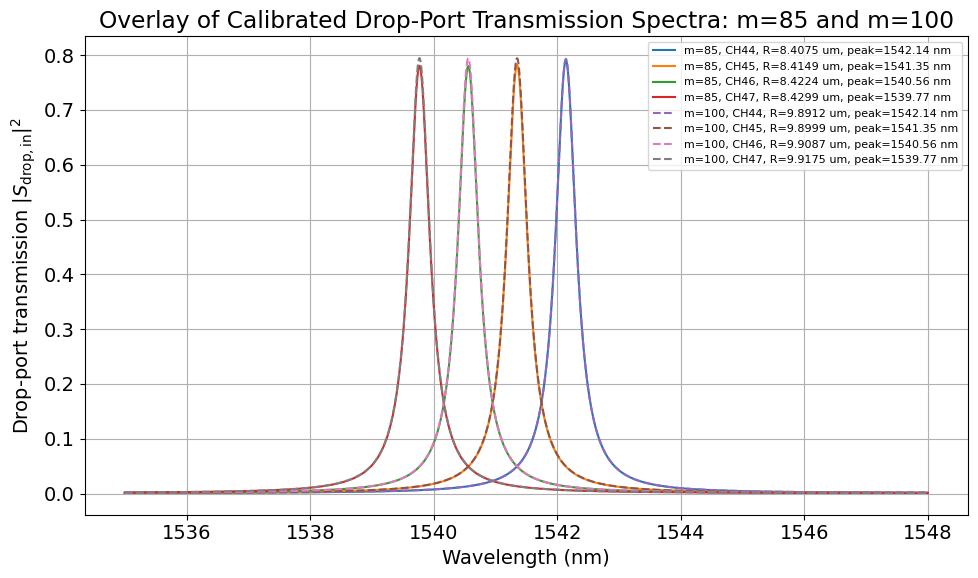

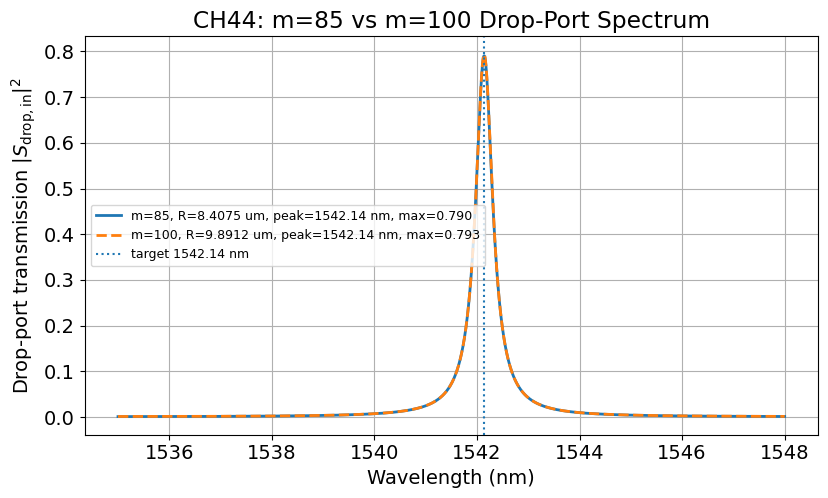

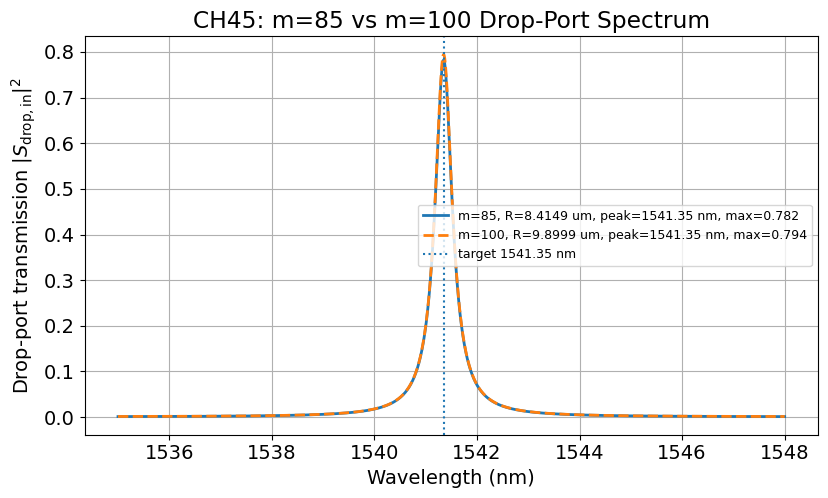

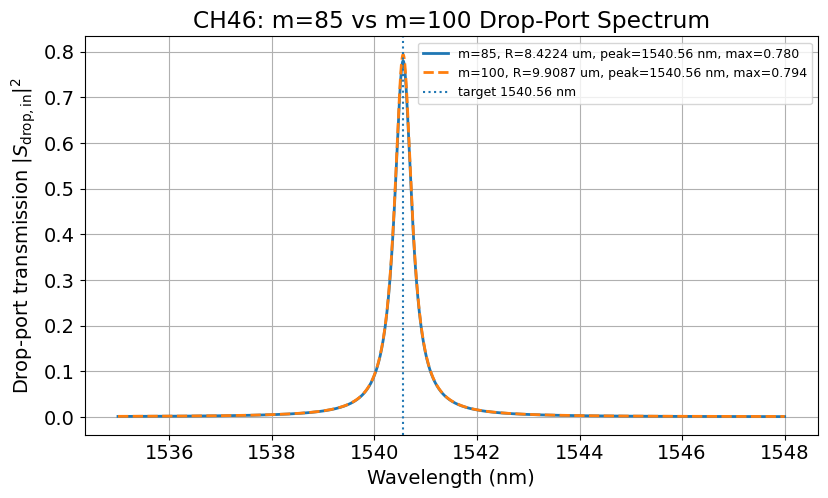

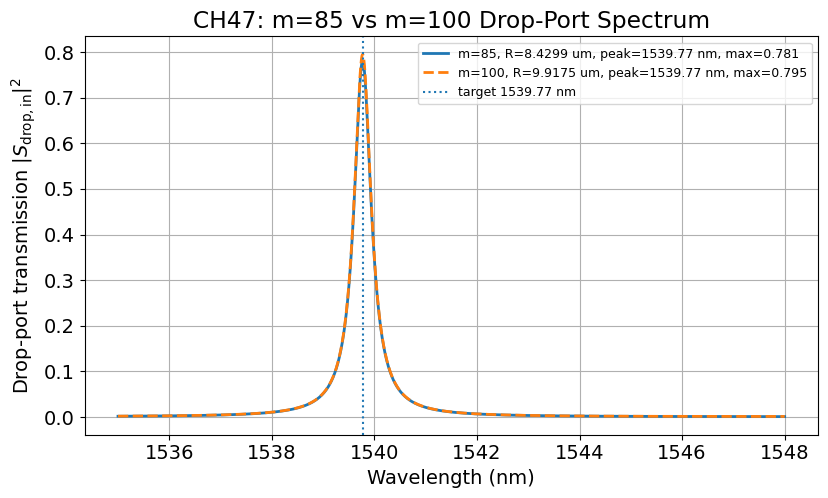

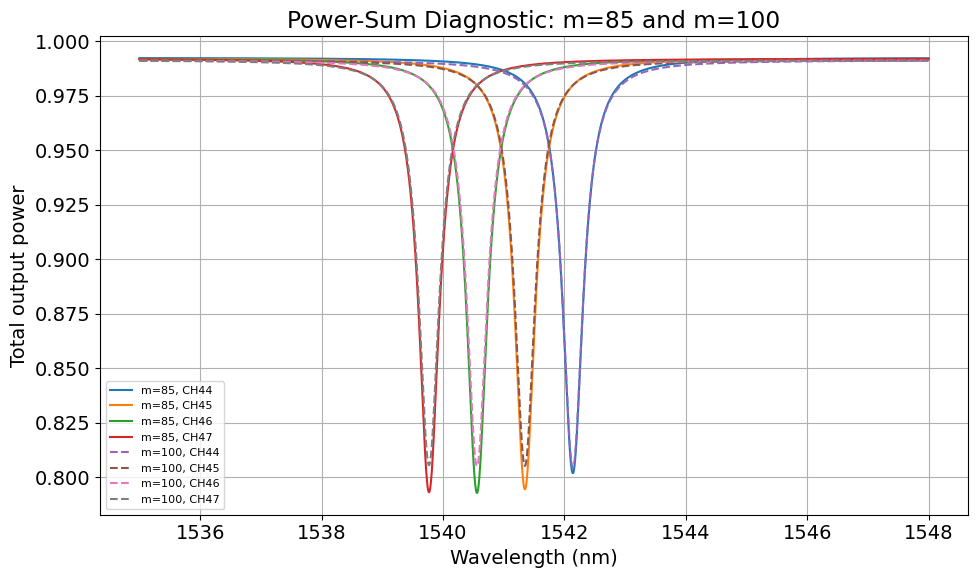


Summary:
    m  channel  radius (um)  target (nm)    peak (nm)   error (nm)     max drop     max Psum
----------------------------------------------------------------------------------------------------
   85     CH44       8.4075    1542.1400    1542.1392      -0.0008     0.790446     0.992177
  100     CH44       9.8912    1542.1400    1542.1392      -0.0008     0.793283     0.990994
   85     CH45       8.4149    1541.3500    1541.3505       0.0005     0.782083     0.991818
  100     CH45       9.8999    1541.3500    1541.3505       0.0005     0.794359     0.991030
   85     CH46       8.4224    1540.5600    1540.5597      -0.0003     0.780167     0.991758
  100     CH46       9.9087    1540.5600    1540.5597      -0.0003     0.794287     0.991033
   85     CH47       8.4299    1539.7700    1539.7710       0.0010     0.780536     0.991789
  100     CH47       9.9175    1539.7700    1539.7710       0.0010     0.794716     0.991054


In [50]:
# ============================================================
# User settings
# ============================================================

BASE_DIR = Path("/Users/princetonwork/ECE559/final/scripts/ring_design")

BATCH_DIRS = {
    85: BASE_DIR / "m__85",
    100: BASE_DIR / "m__100",
}

# Your intended resonant wavelengths for CH44-CH47, in microns.
# These are assigned to tasks sorted by increasing radius.
CHANNEL_LABELS = ["CH44", "CH45", "CH46", "CH47"]
TARGET_LAMBDAS_UM = np.array([
    1.54214,  # CH44
    1.54135,  # CH45
    1.54056,  # CH46
    1.53977,  # CH47
])

# Wavelength sweep range for spectra.
wl_eval = np.linspace(1.535, 1.548, 6001)  # um

# No propagation loss for this comparison.
alpha_power_per_um = 0.0

# Coupling phase sign. If the drop spectra look inverted/incorrect, try -1.
coupling_sign = +1


# ============================================================
# Batch loading and extraction helpers
# ============================================================

def load_local_batch(batch_dir):
    batch_file = batch_dir / "batch.hdf5"
    assert batch_file.exists(), f"Could not find: {batch_file}"

    batch = web.Batch.from_file(str(batch_file))

    try:
        batch_data = batch.load(path_dir=str(batch_dir), skip_download=True)
    except TypeError:
        batch_data = batch.load(path_dir=str(batch_dir))

    return batch_data


def parse_task_name(task_name):
    """
    Parse task names like:
        r_8.4075__g_0.1
    """
    match = re.search(r"r_([0-9.]+)__g_([0-9.]+)", task_name)
    if match is None:
        raise ValueError(f"Could not parse task name: {task_name}")

    r = float(match.group(1))
    g = float(match.group(2))
    return r, g


def get_wavelength_um(sim_data, monitor_name="through"):
    md = sim_data.monitor_data[monitor_name]
    freqs = np.asarray(md.amps.coords["f"].values)
    wl_um = td.C_0 / freqs
    return np.atleast_1d(wl_um)


def get_mode_amp(sim_data, monitor_name, direction="+", mode_index=0):
    """
    Extract complex mode amplitude from a Tidy3D ModeMonitor.
    """
    md = sim_data.monitor_data[monitor_name]
    amps = md.amps

    if "direction" in amps.coords:
        amps = amps.sel(direction=direction)

    if "mode_index" in amps.coords:
        amps = amps.isel(mode_index=mode_index)

    return np.atleast_1d(np.asarray(amps.values).squeeze())


def extract_records_from_batch(batch_data, m_value):
    """
    Extract raw through/coupled amplitudes from all tasks in a batch.

    Assumes available monitors:
        through
        drop
        field

    Uses:
        t_raw     = through monitor amplitude
        kappa_raw = drop monitor amplitude
    """
    records = []

    for task_name, sim_data in batch_data.items():
        r, g = parse_task_name(task_name)

        wl_sim = get_wavelength_um(sim_data, monitor_name="through")

        t_raw = get_mode_amp(
            sim_data,
            monitor_name="through",
            direction="+",
            mode_index=0,
        )

        kappa_raw = get_mode_amp(
            sim_data,
            monitor_name="drop",
            direction="+",
            mode_index=0,
        )

        records.append(
            {
                "m": m_value,
                "task_name": task_name,
                "radius": r,
                "gap": g,
                "wl_sim_um": wl_sim,
                "t_raw": t_raw,
                "kappa_raw": kappa_raw,
                "through_power_raw": np.abs(t_raw) ** 2,
                "kappa_power_raw": np.abs(kappa_raw) ** 2,
                "raw_power_sum": np.abs(t_raw) ** 2 + np.abs(kappa_raw) ** 2,
            }
        )

    # Sort by radius so CH44-CH47 assignment is consistent.
    records = sorted(records, key=lambda rec: rec["radius"])

    if len(records) != len(TARGET_LAMBDAS_UM):
        raise ValueError(
            f"Batch m={m_value} has {len(records)} tasks, but "
            f"{len(TARGET_LAMBDAS_UM)} target wavelengths were provided."
        )

    for i, rec in enumerate(records):
        rec["channel"] = CHANNEL_LABELS[i]
        rec["lambda0_um"] = float(TARGET_LAMBDAS_UM[i])

    return records


# ============================================================
# Passive phase-clean coupler model
# ============================================================

def make_phase_clean_coupler_sdict(t_raw, kappa_raw, wl=1.55, coupling_sign=+1):
    """
    Passive directional coupler using raw magnitudes but not raw Tidy3D phase.

    No power normalization is applied.

    Port convention:
        o1: bottom-left input
        o4: bottom-right through
        o2: top-left ring-side input
        o3: top-right ring-side output
    """
    wl = jnp.asarray(wl)
    ones = jnp.ones_like(wl) + 0j

    t_mag = jnp.abs(jnp.asarray(t_raw))
    k_mag = jnp.abs(jnp.asarray(kappa_raw))

    t = ones * t_mag
    kappa = ones * (coupling_sign * 1j * k_mag)
    z = jnp.zeros_like(t)

    return {
        # Reflections set to zero
        ("o1", "o1"): z,
        ("o2", "o2"): z,
        ("o3", "o3"): z,
        ("o4", "o4"): z,

        # No same-side direct coupling
        ("o2", "o1"): z,
        ("o1", "o2"): z,
        ("o4", "o3"): z,
        ("o3", "o4"): z,

        # Forward paths
        ("o4", "o1"): t,
        ("o3", "o1"): kappa,

        ("o3", "o2"): t,
        ("o4", "o2"): kappa,

        # Reverse paths by reciprocity
        ("o1", "o4"): t,
        ("o1", "o3"): kappa,

        ("o2", "o3"): t,
        ("o2", "o4"): kappa,
    }


def make_phase_clean_coupler_model(t_raw, kappa_raw, coupling_sign=+1):
    def coupler(wl=1.55):
        return make_phase_clean_coupler_sdict(
            t_raw=t_raw,
            kappa_raw=kappa_raw,
            wl=wl,
            coupling_sign=coupling_sign,
        )

    return coupler


# ============================================================
# Calibrated ring propagation model
# ============================================================

def make_calibrated_ring_arc_model(
    radius_um,
    lambda0_um,
    m,
    half=True,
    alpha_power_per_um=0.0,
):
    """
    Ring propagation section with phase calibrated so lambda0_um is resonant.

    Full-ring resonance condition:
        phi(lambda0) = 2*pi*m

    Half-ring arc:
        phi_half(lambda0) = pi*m
    """
    length_um = np.pi * radius_um if half else 2 * np.pi * radius_um
    phase_factor = np.pi * m if half else 2 * np.pi * m

    def arc(wl=1.55):
        wl = jnp.asarray(wl)

        # Constant-neff calibrated phase.
        # This forces resonance at lambda0_um for order m.
        phi = phase_factor * (lambda0_um / wl)

        # Field attenuation from power attenuation alpha.
        amp_loss = jnp.exp(-alpha_power_per_um * length_um / 2)

        a = amp_loss * jnp.exp(-1j * phi)

        return {
            ("o2", "o1"): a,
            ("o1", "o2"): a,
        }

    return arc


def make_full_add_drop_ring_calibrated(
    radius_um,
    lambda0_um,
    t_raw,
    kappa_raw,
    m,
    coupling_sign=+1,
    alpha_power_per_um=0.0,
):
    """
    Full add-drop ring with:
        - two phase-clean passive couplers
        - two calibrated half-ring arcs
        - no normalization of |t| and |kappa|
    """
    coupler = make_phase_clean_coupler_model(
        t_raw=t_raw,
        kappa_raw=kappa_raw,
        coupling_sign=coupling_sign,
    )

    arc = make_calibrated_ring_arc_model(
        radius_um=radius_um,
        lambda0_um=lambda0_um,
        m=m,
        half=True,
        alpha_power_per_um=alpha_power_per_um,
    )

    full_ring, info = sax.circuit(
        netlist={
            "instances": {
                "BOT": coupler,
                "TOP": coupler,
                "ARC_BT": arc,
                "ARC_TB": arc,
            },
            "connections": {
                "BOT,o3": "ARC_BT,o1",
                "ARC_BT,o2": "TOP,o2",

                "TOP,o3": "ARC_TB,o1",
                "ARC_TB,o2": "BOT,o2",
            },
            "ports": {
                "in":   "BOT,o1",
                "thru": "BOT,o4",
                "add":  "TOP,o1",
                "drop": "TOP,o4",
            },
        }
    )

    return full_ring, info


# ============================================================
# Build spectra for m=85 and m=100
# ============================================================

all_records = []
all_spectra = []

for m_value, batch_dir in BATCH_DIRS.items():
    print("=" * 80)
    print(f"Loading m={m_value} batch from:")
    print(batch_dir)

    batch_data = load_local_batch(batch_dir)
    records = extract_records_from_batch(batch_data, m_value=m_value)

    all_records.extend(records)

    for rec in records:
        t_raw = np.atleast_1d(rec["t_raw"])[0]
        kappa_raw = np.atleast_1d(rec["kappa_raw"])[0]

        full_ring, info = make_full_add_drop_ring_calibrated(
            radius_um=rec["radius"],
            lambda0_um=rec["lambda0_um"],
            t_raw=t_raw,
            kappa_raw=kappa_raw,
            m=rec["m"],
            coupling_sign=coupling_sign,
            alpha_power_per_um=alpha_power_per_um,
        )

        S = full_ring(wl=wl_eval)

        T_drop = np.abs(np.asarray(S["drop", "in"])) ** 2
        T_thru = np.abs(np.asarray(S["thru", "in"])) ** 2
        T_add  = np.abs(np.asarray(S["add", "in"])) ** 2
        T_refl = np.abs(np.asarray(S["in", "in"])) ** 2
        P_sum = T_drop + T_thru + T_add + T_refl

        peak_idx = np.argmax(T_drop)
        peak_um = wl_eval[peak_idx]

        spec = {
            **rec,
            "wl_eval": wl_eval,
            "T_drop": T_drop,
            "T_thru": T_thru,
            "T_add": T_add,
            "T_refl": T_refl,
            "P_sum": P_sum,
            "peak_um": peak_um,
            "max_drop": np.max(T_drop),
        }

        all_spectra.append(spec)

        print(
            f"m={rec['m']:3d}, {rec['channel']}, "
            f"R={rec['radius']:.4f} um, "
            f"target={rec['lambda0_um']*1e3:.2f} nm, "
            f"peak={peak_um*1e3:.2f} nm, "
            f"max drop={np.max(T_drop):.4f}, "
            f"raw |t|^2+|k|^2={np.atleast_1d(rec['raw_power_sum'])[0]:.4f}"
        )


# ============================================================
# Plot 1: all drop-port spectra overlaid
# ============================================================
plt.rcParams['font.size'] = 14
plt.figure(figsize=(10, 6))

for spec in all_spectra:
    linestyle = "-" if spec["m"] == 85 else "--"

    plt.plot(
        spec["wl_eval"] * 1e3,
        spec["T_drop"],
        linestyle=linestyle,
        label=(
            f"m={spec['m']}, {spec['channel']}, "
            f"R={spec['radius']:.4f} um, "
            f"peak={spec['peak_um']*1e3:.2f} nm"
        ),
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel(r"Drop-port transmission $|S_{\mathrm{drop,in}}|^2$")
plt.title("Overlay of Calibrated Drop-Port Transmission Spectra: m=85 and m=100")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: one plot per channel, comparing m=85 and m=100
# ============================================================

for ch in CHANNEL_LABELS:
    plt.figure(figsize=(8.5, 5.2))

    specs_ch = [s for s in all_spectra if s["channel"] == ch]
    specs_ch = sorted(specs_ch, key=lambda s: s["m"])

    for spec in specs_ch:
        linestyle = "-" if spec["m"] == 85 else "--"

        plt.plot(
            spec["wl_eval"] * 1e3,
            spec["T_drop"],
            linestyle=linestyle,
            linewidth=2,
            label=(
                f"m={spec['m']}, "
                f"R={spec['radius']:.4f} um, "
                f"peak={spec['peak_um']*1e3:.2f} nm, "
                f"max={spec['max_drop']:.3f}"
            ),
        )

    lambda0_nm = TARGET_LAMBDAS_UM[CHANNEL_LABELS.index(ch)] * 1e3
    plt.axvline(lambda0_nm, linestyle=":", linewidth=1.5, label=f"target {lambda0_nm:.2f} nm")

    plt.xlabel("Wavelength (nm)")
    plt.ylabel(r"Drop-port transmission $|S_{\mathrm{drop,in}}|^2$")
    plt.title(f"{ch}: m=85 vs m=100 Drop-Port Spectrum")
    plt.grid(True)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# ============================================================
# Plot 3: power conservation diagnostic
# ============================================================

plt.figure(figsize=(10, 6))

for spec in all_spectra:
    linestyle = "-" if spec["m"] == 85 else "--"

    plt.plot(
        spec["wl_eval"] * 1e3,
        spec["P_sum"],
        linestyle=linestyle,
        label=f"m={spec['m']}, {spec['channel']}",
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Total output power")
plt.title("Power-Sum Diagnostic: m=85 and m=100")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# Summary table
# ============================================================

print("\nSummary:")
print("=" * 100)
print(
    f"{'m':>5} {'channel':>8} {'radius (um)':>12} {'target (nm)':>12} "
    f"{'peak (nm)':>12} {'error (nm)':>12} {'max drop':>12} {'max Psum':>12}"
)
print("-" * 100)

for spec in sorted(all_spectra, key=lambda s: (s["channel"], s["m"])):
    target_nm = spec["lambda0_um"] * 1e3
    peak_nm = spec["peak_um"] * 1e3
    err_nm = peak_nm - target_nm

    print(
        f"{spec['m']:5d} {spec['channel']:>8} {spec['radius']:12.4f} "
        f"{target_nm:12.4f} {peak_nm:12.4f} {err_nm:12.4f} "
        f"{spec['max_drop']:12.6f} {np.max(spec['P_sum']):12.6f}"
    )

In [51]:
# ============================================================
# Compute FWHM in GHz for m=85 and m=100 drop-port spectra
# Assumes all_spectra exists from previous plotting code.
# Each spec should contain:
#   spec["m"], spec["channel"], spec["radius"], spec["wl_eval"], spec["T_drop"]
# ============================================================

C0_UM_PER_S = 299_792_458 * 1e6  # speed of light in um/s

def interp_crossing(x1, y1, x2, y2, y_target):
    """
    Linear interpolation for x where y crosses y_target.
    """
    if y2 == y1:
        return 0.5 * (x1 + x2)
    return x1 + (y_target - y1) * (x2 - x1) / (y2 - y1)


def compute_fwhm_ghz(wl_um, T, use_baseline=True):
    """
    Compute FWHM of a single drop-port peak.

    Parameters
    ----------
    wl_um:
        Wavelength array in microns.
    T:
        Drop-port transmission array.
    use_baseline:
        If True, computes half maximum relative to the baseline:
            half_level = baseline + (peak - baseline)/2
        If False:
            half_level = peak/2

    Returns
    -------
    dict with peak wavelength, left/right half-max wavelengths, and FWHM in GHz.
    """
    wl_um = np.asarray(wl_um)
    T = np.asarray(T)

    peak_idx = np.argmax(T)
    peak_T = T[peak_idx]
    peak_wl = wl_um[peak_idx]

    baseline = np.min(T) if use_baseline else 0.0
    half_level = baseline + 0.5 * (peak_T - baseline)

    # Left crossing: last point before peak below half-level
    left_candidates = np.where(T[:peak_idx + 1] <= half_level)[0]
    if len(left_candidates) == 0:
        return None

    i_left = left_candidates[-1]
    if i_left == peak_idx:
        return None

    wl_left = interp_crossing(
        wl_um[i_left],
        T[i_left],
        wl_um[i_left + 1],
        T[i_left + 1],
        half_level,
    )

    # Right crossing: first point after peak below half-level
    right_candidates = np.where(T[peak_idx:] <= half_level)[0]
    if len(right_candidates) == 0:
        return None

    i_right = peak_idx + right_candidates[0]
    if i_right == peak_idx:
        return None

    wl_right = interp_crossing(
        wl_um[i_right - 1],
        T[i_right - 1],
        wl_um[i_right],
        T[i_right],
        half_level,
    )

    # Convert half-max wavelength crossings to frequencies.
    f_left_hz = C0_UM_PER_S / wl_left
    f_right_hz = C0_UM_PER_S / wl_right

    fwhm_ghz = abs(f_left_hz - f_right_hz) / 1e9

    return {
        "peak_wl_um": peak_wl,
        "peak_T": peak_T,
        "baseline": baseline,
        "half_level": half_level,
        "wl_left_um": wl_left,
        "wl_right_um": wl_right,
        "fwhm_ghz": fwhm_ghz,
    }


# ============================================================
# Compute and print FWHM values
# ============================================================

fwhm_results = []

for spec in sorted(all_spectra, key=lambda s: (s["channel"], s["m"])):
    result = compute_fwhm_ghz(
        wl_um=spec["wl_eval"],
        T=spec["T_drop"],
        use_baseline=True,
    )

    if result is None:
        print(f"Could not compute FWHM for m={spec['m']}, {spec['channel']}")
        continue

    row = {
        "m": spec["m"],
        "channel": spec["channel"],
        "radius_um": spec["radius"],
        "peak_nm": result["peak_wl_um"] * 1e3,
        "max_drop": result["peak_T"],
        "fwhm_ghz": result["fwhm_ghz"],
        "wl_left_nm": result["wl_left_um"] * 1e3,
        "wl_right_nm": result["wl_right_um"] * 1e3,
    }

    fwhm_results.append(row)


print("=" * 110)
print(
    f"{'m':>5} {'channel':>8} {'radius (um)':>12} "
    f"{'peak (nm)':>12} {'max drop':>12} "
    f"{'left HM (nm)':>14} {'right HM (nm)':>14} {'FWHM (GHz)':>14}"
)
print("-" * 110)

for row in fwhm_results:
    print(
        f"{row['m']:5d} {row['channel']:>8} {row['radius_um']:12.4f} "
        f"{row['peak_nm']:12.4f} {row['max_drop']:12.6f} "
        f"{row['wl_left_nm']:14.4f} {row['wl_right_nm']:14.4f} "
        f"{row['fwhm_ghz']:14.4f}"
    )


# ============================================================
# Compact m=85 vs m=100 comparison by channel
# ============================================================

print("\nComparison by channel:")
print("=" * 80)
print(f"{'channel':>8} {'FWHM m=85 (GHz)':>20} {'FWHM m=100 (GHz)':>22} {'difference':>14}")
print("-" * 80)

for ch in sorted(set(row["channel"] for row in fwhm_results)):
    vals = {row["m"]: row["fwhm_ghz"] for row in fwhm_results if row["channel"] == ch}

    f85 = vals.get(85, np.nan)
    f100 = vals.get(100, np.nan)
    diff = f100 - f85

    print(
        f"{ch:>8} {f85:20.4f} {f100:22.4f} {diff:14.4f}"
    )

    m  channel  radius (um)    peak (nm)     max drop   left HM (nm)  right HM (nm)     FWHM (GHz)
--------------------------------------------------------------------------------------------------------------
   85     CH44       8.4075    1542.1392     0.790446      1541.9364      1542.3436        51.3285
  100     CH44       9.8912    1542.1392     0.793283      1541.9372      1542.3429        51.1432
   85     CH45       8.4149    1541.3505     0.782083      1541.1464      1541.5536        51.3857
  100     CH45       9.8999    1541.3505     0.794359      1541.1473      1541.5528        51.1742
   85     CH46       8.4224    1540.5597     0.780167      1540.3562      1540.7639        51.4965
  100     CH46       9.9087    1540.5597     0.794287      1540.3572      1540.7629        51.2502
   85     CH47       8.4299    1539.7710     0.780536      1539.5663      1539.9738        51.5314
  100     CH47       9.9175    1539.7710     0.794716      1539.5672      1539.9728        51.283